In [1]:
import numpy as np
import openmc
import openmc.stats
import matplotlib.pyplot as plt

In [2]:
###############################################################################
# 1. MATERIALS — AEGIS-HIGA / Gd-155 CONFIGURATION
###############################################################################

import openmc
import numpy as np
import matplotlib.pyplot as plt
import os
import copy
import pandas as pd

INCHES = 2.54

# ---------------------------------------------------------------------------
# UO2 fuel helper
# ---------------------------------------------------------------------------

oxygen_wt = 0.1116

def make_uo2_material(name, enrichment_wt, density=10.257, temperature=900.0):
    """
    Create UO2 material.
    enrichment_wt = U-235 weight fraction inside uranium part.
    Example: 0.026 = 2.6 wt% U-235 in uranium.
    """
    uranium_total_wt = 1.0 - oxygen_wt

    mat = openmc.Material(name=name)
    mat.set_density('g/cm3', density)
    mat.add_nuclide('U235', uranium_total_wt * enrichment_wt, 'wo')
    mat.add_nuclide('U238', uranium_total_wt * (1.0 - enrichment_wt), 'wo')
    mat.add_nuclide('O16', oxygen_wt, 'wo')
    mat.temperature = temperature
    mat.depletable = True

    check_sum = (
        uranium_total_wt * enrichment_wt
        + uranium_total_wt * (1.0 - enrichment_wt)
        + oxygen_wt
    )

    print(f"{name}: enrichment = {enrichment_wt*100:.2f} wt%, sum = {check_sum:.6f}")

    return mat


# ---------------------------------------------------------------------------
# Aegis radial fuel zoning
# ---------------------------------------------------------------------------

enr_inner  = 0.026   # 2.6 wt% U-235
enr_middle = 0.030   # 3.0 wt% U-235
enr_outer  = 0.034   # 3.4 wt% U-235

uo2_16 = make_uo2_material('UO2 inner zone 2.6%', enr_inner)
uo2_24 = make_uo2_material('UO2 middle zone 3.0%', enr_middle)
uo2_31 = make_uo2_material('UO2 outer zone 3.4%', enr_outer)


# ---------------------------------------------------------------------------
# IGD fuel material — UO2-Gd2O3 fuel rod, Gd-155 enriched
# ---------------------------------------------------------------------------
# IGD is still fuel, unlike HIGA.
# It gives early-cycle reactivity suppression.

gd_total_wt = 0.020      # 2.0 wt% represented Gd in IGD rods
gd155_frac = 1.0         # enriched Gd-155
gd157_frac = 0.0

gd_u_enrichment = 0.030  # 3.0 wt% U-235 in uranium part of IGD fuel
gd_density = 10.2

uranium_total_wt_gd = 1.0 - oxygen_wt - gd_total_wt

if uranium_total_wt_gd <= 0.0:
    raise ValueError("Gd + oxygen weight fractions are too large.")

gd_fuel = openmc.Material(name=f'UO2-IGD {gd_total_wt*100:.1f} wt% Gd155')
gd_fuel.set_density('g/cm3', gd_density)

gd_fuel.add_nuclide('U235', uranium_total_wt_gd * gd_u_enrichment, 'wo')
gd_fuel.add_nuclide('U238', uranium_total_wt_gd * (1.0 - gd_u_enrichment), 'wo')
gd_fuel.add_nuclide('Gd155', gd_total_wt * gd155_frac, 'wo')

if gd157_frac > 0.0:
    gd_fuel.add_nuclide('Gd157', gd_total_wt * gd157_frac, 'wo')

gd_fuel.add_nuclide('O16', oxygen_wt, 'wo')
gd_fuel.temperature = 900.0
gd_fuel.depletable = True

print("=" * 72)
print("IGD fuel material created")
print("=" * 72)
print(f"IGD Gd total wt fraction = {gd_total_wt:.5f}")
print(f"IGD Gd isotope           = Gd155")
print(f"IGD uranium enrichment   = {gd_u_enrichment*100:.2f} wt%")
print("=" * 72)


# ---------------------------------------------------------------------------
# HIGA absorber material — Gd2O3/Al2O3, Gd-155 enriched
# ---------------------------------------------------------------------------
# HIGA is NOT fuel.
# It is a discrete absorber rod using Gd2O3 + Al2O3.

HIGA_GD2O3_MOL_PERCENT = 12
HIGA_GD_MODE = "Gd155"   # options: "natural", "Gd155", "Gd157"

def configure_higa_material(
    higa,
    gd2o3_mol_percent=13.0,
    gd_mode="Gd155",
    temperature=900.0
):
    """
    Configure existing HIGA material object in-place.
    This avoids geometry pointing to an older HIGA object.
    """

    x = gd2o3_mol_percent / 100.0

    if x <= 0.0 or x >= 1.0:
        raise ValueError("gd2o3_mol_percent must be between 0 and 100.")

    # Clear old composition when rerunning this cell
    higa._nuclides = []

    # Approximate mixture density
    M_Gd2O3 = 362.50
    M_Al2O3 = 101.96
    rho_Gd2O3 = 7.41
    rho_Al2O3 = 3.97

    mass_mix = x * M_Gd2O3 + (1.0 - x) * M_Al2O3
    vol_mix = x * M_Gd2O3 / rho_Gd2O3 + (1.0 - x) * M_Al2O3 / rho_Al2O3
    rho_mix = mass_mix / vol_mix

    higa.name = f"HIGA {gd2o3_mol_percent:.1f} mol% Gd2O3 {gd_mode}"
    higa.set_density("g/cm3", rho_mix)

    if gd_mode == "natural":
        higa.add_element("Gd", 2.0 * x, "ao")
    elif gd_mode == "Gd155":
        higa.add_nuclide("Gd155", 2.0 * x, "ao")
    elif gd_mode == "Gd157":
        higa.add_nuclide("Gd157", 2.0 * x, "ao")
    else:
        raise ValueError("gd_mode must be 'natural', 'Gd155', or 'Gd157'.")

    higa.add_element("Al", 2.0 * (1.0 - x), "ao")
    higa.add_nuclide("O16", 3.0, "ao")

    higa.temperature = temperature
    higa.depletable = True

    print("=" * 72)
    print("HIGA absorber material configured")
    print("=" * 72)
    print(f"HIGA material id     = {higa.id}")
    print(f"HIGA material name   = {higa.name}")
    print(f"Gd2O3 content        = {gd2o3_mol_percent:.2f} mol%")
    print(f"Gd isotope mode      = {gd_mode}")
    print(f"Estimated density    = {rho_mix:.4f} g/cm3")
    print("=" * 72)


try:
    higa_absorber
except NameError:
    higa_absorber = openmc.Material(name="HIGA placeholder")

configure_higa_material(
    higa_absorber,
    gd2o3_mol_percent=HIGA_GD2O3_MOL_PERCENT,
    gd_mode=HIGA_GD_MODE,
    temperature=900.0
)


# ---------------------------------------------------------------------------
# Other materials
# ---------------------------------------------------------------------------

helium = openmc.Material(name='Helium')
helium.set_density('g/cm3', 0.000178)
helium.add_element('He', 1.0)

zirc4 = openmc.Material(name='Zircaloy-4')
zirc4.set_density('g/cm3', 6.56)
zirc4.add_element('Zr', 0.98197, 'wo')
zirc4.add_element('Sn', 0.01450, 'wo')
zirc4.add_element('Fe', 0.00210, 'wo')
zirc4.add_element('Cr', 0.00100, 'wo')
zirc4.add_element('Hf', 0.00043, 'wo')

water = openmc.Material(name='Light Water')
water.set_density('g/cm3', 0.7405)
water.add_nuclide('H1', 2.0, 'ao')
water.add_nuclide('O16', 1.0, 'ao')
water.add_s_alpha_beta('c_H_in_H2O')
water.temperature = 557.0

ss304 = openmc.Material(name='SS304')
ss304.set_density('g/cm3', 8.03)
ss304.add_element('Fe', 0.695, 'wo')
ss304.add_element('Cr', 0.190, 'wo')
ss304.add_element('Ni', 0.095, 'wo')
ss304.add_element('Mn', 0.020, 'wo')

cs = openmc.Material(name='Carbon Steel RPV')
cs.set_density('g/cm3', 7.85)
cs.add_element('Fe', 0.975, 'wo')
cs.add_element('Mn', 0.015, 'wo')
cs.add_element('Si', 0.005, 'wo')
cs.add_element('Cr', 0.005, 'wo')


# ---------------------------------------------------------------------------
# Collect materials
# ---------------------------------------------------------------------------

materials = openmc.Materials([
    uo2_16, uo2_24, uo2_31,
    gd_fuel,
    higa_absorber,
    helium, zirc4, water, ss304, cs
])
materials.cross_sections='/mnt/d/openmc_data/endfb-viii.0-hdf5/cross_sections.xml'
materials.export_to_xml()

print("✓ materials.xml exported")
print("Materials:")
for mat in materials:
    print(f" - {mat.id}: {mat.name}")

UO2 inner zone 2.6%: enrichment = 2.60 wt%, sum = 1.000000
UO2 middle zone 3.0%: enrichment = 3.00 wt%, sum = 1.000000
UO2 outer zone 3.4%: enrichment = 3.40 wt%, sum = 1.000000
IGD fuel material created
IGD Gd total wt fraction = 0.02000
IGD Gd isotope           = Gd155
IGD uranium enrichment   = 3.00 wt%
HIGA absorber material configured
HIGA material id     = 5
HIGA material name   = HIGA 12.0 mol% Gd2O3 Gd155
Gd2O3 content        = 12.00 mol%
Gd isotope mode      = Gd155
Estimated density    = 4.6793 g/cm3
✓ materials.xml exported
Materials:
 - 1: UO2 inner zone 2.6%
 - 2: UO2 middle zone 3.0%
 - 3: UO2 outer zone 3.4%
 - 4: UO2-IGD 2.0 wt% Gd155
 - 5: HIGA 12.0 mol% Gd2O3 Gd155
 - 6: Helium
 - 7: Zircaloy-4
 - 8: Light Water
 - 9: SS304
 - 10: Carbon Steel RPV


In [3]:
###############################################################################
# 2. GEOMETRY — COMPACT AEGIS-HIGA DIMENSIONS
###############################################################################

pellet_OR = 0.4025
clad_IR   = 0.4135
clad_OR   = 0.4725

gap_thickness = clad_IR - pellet_OR
clad_thickness = clad_OR - clad_IR

if gap_thickness <= 0.0:
    raise ValueError("Invalid fuel rod geometry: clad_IR must be larger than pellet_OR.")

if clad_thickness <= 0.0:
    raise ValueError("Invalid cladding geometry: clad_OR must be larger than clad_IR.")

gt_IR = 0.5650
gt_OR = 0.6050

pin_pitch = 1.2550
assy_pitch = 21.4200

if 17 * pin_pitch > assy_pitch:
    raise ValueError("17 pin pitches exceed assembly pitch.")

active_height = 190.0
z_bot = -active_height / 2.0
z_top =  active_height / 2.0

axial_reflector_thickness = 22.5

core_barrel_IR = 92.5
core_barrel_OR = 97.0

rpv_IR = 113.0
rpv_OR = 122.0

if rpv_IR <= core_barrel_OR:
    raise ValueError("RPV IR must be larger than core barrel OR.")

downcomer_gap = rpv_IR - core_barrel_OR
rpv_thickness = rpv_OR - rpv_IR

print("── Aegis-HIGA compact dimensions [cm] ──")
print(f"Pellet OR                 = {pellet_OR:.4f}")
print(f"Clad IR / OR              = {clad_IR:.4f} / {clad_OR:.4f}")
print(f"Gap thickness             = {gap_thickness:.4f}")
print(f"Clad thickness            = {clad_thickness:.4f}")
print(f"Guide tube IR / OR        = {gt_IR:.4f} / {gt_OR:.4f}")
print(f"Pin pitch                 = {pin_pitch:.4f}")
print(f"Assembly pitch            = {assy_pitch:.4f}")
print(f"Active height             = {active_height:.2f}")
print(f"Core barrel IR / OR       = {core_barrel_IR:.2f} / {core_barrel_OR:.2f}")
print(f"RPV IR / OR               = {rpv_IR:.2f} / {rpv_OR:.2f}")
print(f"RPV outer diameter        = {2 * rpv_OR:.2f}")
print(f"Downcomer radial gap      = {downcomer_gap:.2f}")
print(f"RPV steel thickness       = {rpv_thickness:.2f}")

── Aegis-HIGA compact dimensions [cm] ──
Pellet OR                 = 0.4025
Clad IR / OR              = 0.4135 / 0.4725
Gap thickness             = 0.0110
Clad thickness            = 0.0590
Guide tube IR / OR        = 0.5650 / 0.6050
Pin pitch                 = 1.2550
Assembly pitch            = 21.4200
Active height             = 190.00
Core barrel IR / OR       = 92.50 / 97.00
RPV IR / OR               = 113.00 / 122.00
RPV outer diameter        = 244.00
Downcomer radial gap      = 16.00
RPV steel thickness       = 9.00


In [4]:
###############################################################################
# 2b. GEOMETRY — PIN AND ROD UNIVERSES
###############################################################################

# ---------------------------------------------------------------------------
# Surfaces
# ---------------------------------------------------------------------------

s_fuel = openmc.ZCylinder(r=pellet_OR, name='Fuel pellet OR')
s_clad_ir = openmc.ZCylinder(r=clad_IR, name='Clad IR')
s_clad_or = openmc.ZCylinder(r=clad_OR, name='Clad OR')

s_gt_ir = openmc.ZCylinder(r=gt_IR, name='Guide tube IR')
s_gt_or = openmc.ZCylinder(r=gt_OR, name='Guide tube OR')


def make_fuel_pin(fuel_mat, name):
    c_fuel = openmc.Cell(name=f'{name} fuel', fill=fuel_mat, region=-s_fuel)
    c_gap = openmc.Cell(name=f'{name} gap', fill=helium, region=+s_fuel & -s_clad_ir)
    c_clad = openmc.Cell(name=f'{name} cladding', fill=zirc4, region=+s_clad_ir & -s_clad_or)
    c_water = openmc.Cell(name=f'{name} water', fill=water, region=+s_clad_or)

    return openmc.Universe(
        name=name,
        cells=[c_fuel, c_gap, c_clad, c_water]
    )


pin_16 = make_fuel_pin(uo2_16, 'Fuel pin inner 2.6%')
pin_24 = make_fuel_pin(uo2_24, 'Fuel pin middle 3.0%')
pin_31 = make_fuel_pin(uo2_31, 'Fuel pin outer 3.4%')
pin_gd = make_fuel_pin(gd_fuel, 'IGD fuel pin Gd155')


# ---------------------------------------------------------------------------
# Guide tube universe
# ---------------------------------------------------------------------------

c_gt_water_inside = openmc.Cell(
    name='Guide tube water inside',
    fill=water,
    region=-s_gt_ir
)

c_gt_clad = openmc.Cell(
    name='Guide tube cladding',
    fill=zirc4,
    region=+s_gt_ir & -s_gt_or
)

c_gt_water_outside = openmc.Cell(
    name='Guide tube surrounding water',
    fill=water,
    region=+s_gt_or
)

guide_tube = openmc.Universe(
    name='Guide tube universe',
    cells=[c_gt_water_inside, c_gt_clad, c_gt_water_outside]
)


# ---------------------------------------------------------------------------
# HIGA rod universe
# ---------------------------------------------------------------------------
# HIGA is non-fuel absorber inside cladding.

s_higa_pellet = openmc.ZCylinder(r=pellet_OR, name='HIGA absorber pellet OR')
s_higa_clad_ir = openmc.ZCylinder(r=clad_IR, name='HIGA clad IR')
s_higa_clad_or = openmc.ZCylinder(r=clad_OR, name='HIGA clad OR')

c_higa_abs = openmc.Cell(
    name='HIGA absorber pellet',
    fill=higa_absorber,
    region=-s_higa_pellet
)

c_higa_gap = openmc.Cell(
    name='HIGA helium gap',
    fill=helium,
    region=+s_higa_pellet & -s_higa_clad_ir
)

c_higa_clad = openmc.Cell(
    name='HIGA cladding',
    fill=zirc4,
    region=+s_higa_clad_ir & -s_higa_clad_or
)

c_higa_water = openmc.Cell(
    name='HIGA surrounding water',
    fill=water,
    region=+s_higa_clad_or
)

pin_higa = openmc.Universe(
    name='HIGA rod universe',
    cells=[c_higa_abs, c_higa_gap, c_higa_clad, c_higa_water]
)

print("✓ Fuel pins, IGD pins, guide tubes, and HIGA rods created")

✓ Fuel pins, IGD pins, guide tubes, and HIGA rods created


In [5]:
###############################################################################
# 2c. GEOMETRY — 17×17 ASSEMBLIES WITH HIGA + IGD
###############################################################################

gt_positions = {
    (2, 5), (2, 8), (2, 11),
    (3, 3), (3, 13),
    (5, 2), (5, 5), (5, 8), (5, 11), (5, 14),
    (8, 2), (8, 5), (8, 8), (8, 11), (8, 14),
    (11, 2), (11, 5), (11, 8), (11, 11), (11, 14),
    (13, 3), (13, 13),
    (14, 5), (14, 8), (14, 11),
}

# 16 HIGA rods per assembly
higa_positions = {
    (4, 4), (4, 12), (12, 4), (12, 12),
    (3, 8), (8, 3), (8, 13), (13, 8),
    (6, 6), (6, 10), (10, 6), (10, 10),
    (4, 8), (8, 4), (8, 12), (12, 8),
}

igd_positions = set()


# Safety checks
if higa_positions.intersection(gt_positions):
    raise ValueError(f"HIGA overlaps guide tubes: {higa_positions.intersection(gt_positions)}")

if igd_positions.intersection(gt_positions):
    raise ValueError(f"IGD overlaps guide tubes: {igd_positions.intersection(gt_positions)}")

if higa_positions.intersection(igd_positions):
    raise ValueError(f"HIGA overlaps IGD: {higa_positions.intersection(igd_positions)}")

print("=" * 72)
print("Assembly absorber pattern")
print("=" * 72)
print(f"Guide tubes / assembly = {len(gt_positions)}")
print(f"HIGA rods / assembly   = {len(higa_positions)}")
print(f"IGD rods / assembly    = {len(igd_positions)}")
print("=" * 72)


def make_assembly(fuel_pin, enrichment_tag):
    univs = np.empty((17, 17), dtype=openmc.Universe)

    for i in range(17):
        for j in range(17):
            if (i, j) in gt_positions:
                univs[i, j] = guide_tube
            elif (i, j) in higa_positions:
                univs[i, j] = pin_higa
            elif (i, j) in igd_positions:
                univs[i, j] = pin_gd
            else:
                univs[i, j] = fuel_pin

    lattice = openmc.RectLattice(name=f'FA {enrichment_tag}')
    lattice.lower_left = (-17 * pin_pitch / 2.0, -17 * pin_pitch / 2.0)
    lattice.pitch = (pin_pitch, pin_pitch)
    lattice.universes = univs

    water_universe = openmc.Universe(cells=[openmc.Cell(fill=water)])
    lattice.outer = water_universe

    assy_box = openmc.model.RectangularPrism(
        width=assy_pitch,
        height=assy_pitch,
        origin=(0.0, 0.0)
    )

    c_lat = openmc.Cell(
        name=f'lattice {enrichment_tag}',
        fill=lattice,
        region=-assy_box
    )

    c_outer = openmc.Cell(
        name=f'inter-assembly water {enrichment_tag}',
        fill=water,
        region=+assy_box
    )

    return openmc.Universe(
        name=f'Assembly {enrichment_tag}',
        cells=[c_lat, c_outer]
    )


assy_16 = make_assembly(pin_16, 'inner 2.6% HIGA')
assy_24 = make_assembly(pin_24, 'middle 3.0% HIGA')
assy_31 = make_assembly(pin_31, 'outer 3.4% HIGA')

water_cell_univ = openmc.Universe(
    name='Water universe',
    cells=[openmc.Cell(fill=water)]
)

print("✓ HIGA + IGD assemblies created")

Assembly absorber pattern
Guide tubes / assembly = 25
HIGA rods / assembly   = 16
IGD rods / assembly    = 0
✓ HIGA + IGD assemblies created


Aegis-HIGA core map
Fuel assemblies        = 37
A/B/C assemblies       = 9/12/16
Core lattice width     = 192.78 cm
LR symmetric?          = True
UD symmetric?          = True
Transpose symmetric?   = True


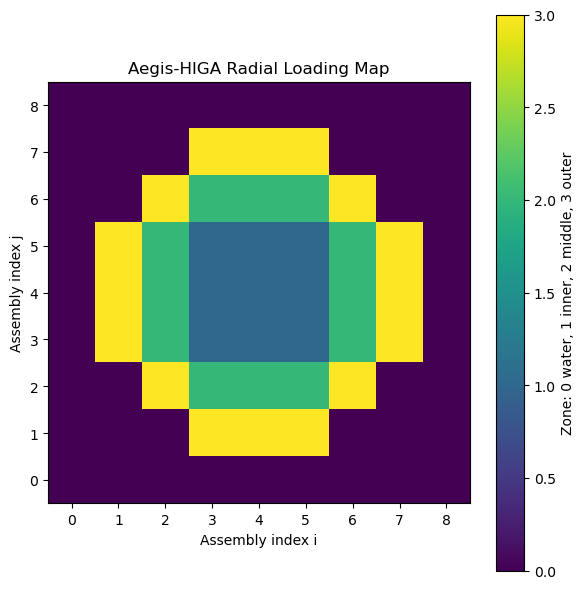

In [6]:
###############################################################################
# 2d. GEOMETRY — FULL-CORE 9×9 HIGA LOADING MAP
###############################################################################

W = water_cell_univ

A = assy_16
B = assy_24
C = assy_31

core_map = [
    [W, W, W, W, W, W, W, W, W],
    [W, W, W, C, C, C, W, W, W],
    [W, W, C, B, B, B, C, W, W],
    [W, C, B, A, A, A, B, C, W],
    [W, C, B, A, A, A, B, C, W],
    [W, C, B, A, A, A, B, C, W],
    [W, W, C, B, B, B, C, W, W],
    [W, W, W, C, C, C, W, W, W],
    [W, W, W, W, W, W, W, W, W],
]

core_array = np.array(core_map, dtype=object)

core_lattice = openmc.RectLattice(name='Aegis-HIGA radial-zoned core lattice')
core_lattice.pitch = (assy_pitch, assy_pitch)

core_width = 9 * assy_pitch
core_lattice.lower_left = (-core_width / 2.0, -core_width / 2.0)
core_lattice.universes = core_array

outer_water = openmc.Universe(
    name='Outer water universe',
    cells=[openmc.Cell(fill=water)]
)
core_lattice.outer = outer_water

n_A = sum(1 for row in core_map for u in row if u is A)
n_B = sum(1 for row in core_map for u in row if u is B)
n_C = sum(1 for row in core_map for u in row if u is C)
n_fuel = n_A + n_B + n_C

zone_map = np.zeros((9, 9), dtype=int)

for i in range(9):
    for j in range(9):
        u = core_map[i][j]
        if u is A:
            zone_map[i, j] = 1
        elif u is B:
            zone_map[i, j] = 2
        elif u is C:
            zone_map[i, j] = 3
        else:
            zone_map[i, j] = 0

print("=" * 72)
print("Aegis-HIGA core map")
print("=" * 72)
print(f"Fuel assemblies        = {n_fuel}")
print(f"A/B/C assemblies       = {n_A}/{n_B}/{n_C}")
print(f"Core lattice width     = {core_width:.2f} cm")
print(f"LR symmetric?          = {np.all(zone_map == np.fliplr(zone_map))}")
print(f"UD symmetric?          = {np.all(zone_map == np.flipud(zone_map))}")
print(f"Transpose symmetric?   = {np.all(zone_map == zone_map.T)}")
print("=" * 72)

plt.figure(figsize=(6, 6))
plt.imshow(zone_map.T, origin='lower')
plt.colorbar(label='Zone: 0 water, 1 inner, 2 middle, 3 outer')
plt.xlabel('Assembly index i')
plt.ylabel('Assembly index j')
plt.title('Aegis-HIGA Radial Loading Map')
plt.tight_layout()
plt.savefig('aegis40_higa_core_zoning_map.png', dpi=250)
plt.show()

In [7]:
###############################################################################
# 2e. GEOMETRY — ROOT GEOMETRY
###############################################################################

fuel_assembly_half = assy_pitch / 2.0
max_fuel_corner_radius = 0.0

for row_idx in range(9):
    for col_idx in range(9):
        u = core_map[row_idx][col_idx]

        if u in [A, B, C]:
            x_center = -core_width / 2.0 + (col_idx + 0.5) * assy_pitch
            y_center = -core_width / 2.0 + (row_idx + 0.5) * assy_pitch

            for dx in [-fuel_assembly_half, fuel_assembly_half]:
                for dy in [-fuel_assembly_half, fuel_assembly_half]:
                    r_corner = np.sqrt((x_center + dx)**2 + (y_center + dy)**2)
                    max_fuel_corner_radius = max(max_fuel_corner_radius, r_corner)

fuel_to_barrel_clearance = core_barrel_IR - max_fuel_corner_radius

if fuel_to_barrel_clearance <= 0.0:
    raise ValueError("Fuel assemblies do not fit inside barrel.")

s_barrel_in  = openmc.ZCylinder(r=core_barrel_IR, name='Core barrel IR')
s_barrel_out = openmc.ZCylinder(r=core_barrel_OR, name='Core barrel OR')
s_rpv_in     = openmc.ZCylinder(r=rpv_IR, name='RPV IR')

s_rpv_out = openmc.ZCylinder(
    r=rpv_OR,
    name='RPV OR',
    boundary_type='vacuum'
)

z_lower_refl = z_bot - axial_reflector_thickness
z_upper_refl = z_top + axial_reflector_thickness

s_zbot = openmc.ZPlane(
    z0=z_lower_refl,
    name='Bottom boundary',
    boundary_type='vacuum'
)

s_ztop = openmc.ZPlane(
    z0=z_upper_refl,
    name='Top boundary',
    boundary_type='vacuum'
)

s_zfbot = openmc.ZPlane(z0=z_bot, name='Fuel bottom')
s_zftop = openmc.ZPlane(z0=z_top, name='Fuel top')

c_core = openmc.Cell(
    name='Active core',
    fill=core_lattice,
    region=-s_barrel_in & +s_zfbot & -s_zftop
)

c_lower_refl = openmc.Cell(
    name='Lower reflector',
    fill=water,
    region=-s_barrel_in & +s_zbot & -s_zfbot
)

c_upper_refl = openmc.Cell(
    name='Upper reflector',
    fill=water,
    region=-s_barrel_in & +s_zftop & -s_ztop
)

c_barrel = openmc.Cell(
    name='Core barrel',
    fill=ss304,
    region=+s_barrel_in & -s_barrel_out & +s_zbot & -s_ztop
)

c_downcomer = openmc.Cell(
    name='Downcomer',
    fill=water,
    region=+s_barrel_out & -s_rpv_in & +s_zbot & -s_ztop
)

c_rpv = openmc.Cell(
    name='RPV',
    fill=cs,
    region=+s_rpv_in & -s_rpv_out & +s_zbot & -s_ztop
)

root = openmc.Universe(name='Root universe')
root.add_cells([
    c_core,
    c_lower_refl,
    c_upper_refl,
    c_barrel,
    c_downcomer,
    c_rpv
])

geometry = openmc.Geometry(root)
geometry.export_to_xml()

print("=" * 72)
print("Aegis-HIGA geometry exported")
print("=" * 72)
print(f"Active height                   = {active_height:.1f} cm")
print(f"Total modeled height            = {z_upper_refl - z_lower_refl:.1f} cm")
print(f"Max fuel assembly corner radius = {max_fuel_corner_radius:.2f} cm")
print(f"Core barrel IR                  = {core_barrel_IR:.2f} cm")
print(f"Fuel-to-barrel clearance        = {fuel_to_barrel_clearance:.2f} cm")
print(f"RPV outer diameter              = {2 * rpv_OR:.2f} cm")
print("Outer boundaries                = vacuum")
print("=" * 72)

Aegis-HIGA geometry exported
Active height                   = 190.0 cm
Total modeled height            = 235.0 cm
Max fuel assembly corner radius = 81.56 cm
Core barrel IR                  = 92.50 cm
Fuel-to-barrel clearance        = 10.94 cm
RPV outer diameter              = 244.00 cm
Outer boundaries                = vacuum


In [8]:
###############################################################################
# 3. SETTINGS — QUICK / FINAL
###############################################################################

settings = openmc.Settings()

RUN_QUALITY = "quick"   # "quick" or "final"

if RUN_QUALITY == "quick":
    settings.batches = 300
    settings.inactive = 120
    settings.particles = 10000

elif RUN_QUALITY == "final":
    settings.batches = 650
    settings.inactive = 150
    settings.particles = 10000

else:
    raise ValueError("RUN_QUALITY must be 'quick' or 'final'.")

settings.seed = 2026
settings.run_mode = 'eigenvalue'

lower_left  = (-core_barrel_IR, -core_barrel_IR, z_bot)
upper_right = ( core_barrel_IR,  core_barrel_IR, z_top)

uniform_dist = openmc.stats.Box(lower_left, upper_right)

settings.source = openmc.IndependentSource(
    space=uniform_dist,
    constraints={'fissionable': True}
)

settings.temperature = {
    'default': 557.0,
    'method': 'interpolation'
}

entropy_mesh = openmc.RegularMesh(name='Entropy mesh')
entropy_mesh.dimension = [9, 9, 10]
entropy_mesh.lower_left = [-core_barrel_IR, -core_barrel_IR, z_bot]
entropy_mesh.upper_right = [ core_barrel_IR,  core_barrel_IR, z_top]

settings.entropy_mesh = entropy_mesh
settings.output = {'tallies': True}

settings.export_to_xml()

print("=" * 72)
print("settings.xml exported")
print("=" * 72)
print(f"Run quality       = {RUN_QUALITY}")
print(f"Batches           = {settings.batches}")
print(f"Inactive          = {settings.inactive}")
print(f"Particles/batch   = {settings.particles}")
print("Source constraint = fissionable only")
print("=" * 72)

settings.xml exported
Run quality       = quick
Batches           = 300
Inactive          = 120
Particles/batch   = 10000
Source constraint = fissionable only


In [9]:
###############################################################################
# 4. TALLIES — BOL HIGA CASE
###############################################################################

tallies = openmc.Tallies()

# ---------------------------------------------------------------------------
# Energy groups
# ---------------------------------------------------------------------------

energy_bins = [1.0e-5, 0.625, 1.0e5, 20.0e6]
energy_filter = openmc.EnergyFilter(energy_bins)

# ---------------------------------------------------------------------------
# Fuel material filters
# ---------------------------------------------------------------------------

fuel_mats = [uo2_16, uo2_24, uo2_31]

if len(igd_positions) > 0:
    fuel_mats.append(gd_fuel)

fuel_mat_filter = openmc.MaterialFilter(fuel_mats)

# ---------------------------------------------------------------------------
# Fuel flux by energy
# ---------------------------------------------------------------------------

t_flux = openmc.Tally(name='Fuel flux (energy-resolved)')
t_flux.filters = [fuel_mat_filter, energy_filter]
t_flux.scores = ['flux']
tallies.append(t_flux)

# ---------------------------------------------------------------------------
# Fission rates
# ---------------------------------------------------------------------------

t_fis = openmc.Tally(name='Fission rates')
t_fis.filters = [fuel_mat_filter]
t_fis.scores = ['fission', 'nu-fission', 'kappa-fission']
tallies.append(t_fis)

# ---------------------------------------------------------------------------
# Fuel heating
# ---------------------------------------------------------------------------

t_heat = openmc.Tally(name='Fuel heating')
t_heat.filters = [fuel_mat_filter]
t_heat.scores = ['heating']
tallies.append(t_heat)

# ---------------------------------------------------------------------------
# Total heating
# ---------------------------------------------------------------------------

t_total_heat = openmc.Tally(name='Total heating')
t_total_heat.scores = ['heating']
tallies.append(t_total_heat)

# ---------------------------------------------------------------------------
# HIGA absorption
# ---------------------------------------------------------------------------

t_higa_abs = openmc.Tally(name='HIGA absorption')
t_higa_abs.filters = [openmc.MaterialFilter([higa_absorber]), energy_filter]
t_higa_abs.scores = ['absorption']
tallies.append(t_higa_abs)

# ---------------------------------------------------------------------------
# XY midplane mesh
# ---------------------------------------------------------------------------

mesh_xy = openmc.RegularMesh(name='XY midplane mesh')
mesh_xy.dimension = [120, 120, 1]

z_slice = 5.0

mesh_xy.lower_left  = [-rpv_OR, -rpv_OR, -z_slice / 2.0]
mesh_xy.upper_right = [ rpv_OR,  rpv_OR,  z_slice / 2.0]

t_mesh_xy = openmc.Tally(name='Mesh XY midplane')
t_mesh_xy.filters = [openmc.MeshFilter(mesh_xy)]
t_mesh_xy.scores  = ['flux', 'kappa-fission', 'heating']
tallies.append(t_mesh_xy)

# ---------------------------------------------------------------------------
# 3D full-core mesh
# ---------------------------------------------------------------------------

mesh_3d = openmc.RegularMesh(name='Mesh 3D flux power')
mesh_3d.dimension = [60, 60, 40]
mesh_3d.lower_left  = [-rpv_OR, -rpv_OR, z_bot]
mesh_3d.upper_right = [ rpv_OR,  rpv_OR, z_top]

t_mesh_3d = openmc.Tally(name='Mesh 3D flux power')
t_mesh_3d.filters = [openmc.MeshFilter(mesh_3d)]
t_mesh_3d.scores = ['flux', 'kappa-fission', 'heating']
tallies.append(t_mesh_3d)

# ---------------------------------------------------------------------------
# Assembly power map
# ---------------------------------------------------------------------------

mesh_assy = openmc.RegularMesh(name='Assembly power mesh')
mesh_assy.dimension = [9, 9, 1]
mesh_assy.lower_left  = [-core_width / 2.0, -core_width / 2.0, z_bot]
mesh_assy.upper_right = [ core_width / 2.0,  core_width / 2.0, z_top]

t_assy_power = openmc.Tally(name='Assembly power map')
t_assy_power.filters = [openmc.MeshFilter(mesh_assy)]
t_assy_power.scores = ['kappa-fission', 'heating']
tallies.append(t_assy_power)

tallies.export_to_xml()

print("=" * 72)
print("tallies.xml exported")
print("=" * 72)
print(f"Fuel materials in tallies:")
for mat in fuel_mats:
    print(f" - {mat.name}")
print(f"HIGA absorber tally       = {higa_absorber.name}")
print(f"Number of tallies         = {len(tallies)}")
print("=" * 72)

tallies.xml exported
Fuel materials in tallies:
 - UO2 inner zone 2.6%
 - UO2 middle zone 3.0%
 - UO2 outer zone 3.4%
HIGA absorber tally       = HIGA 12.0 mol% Gd2O3 Gd155
Number of tallies         = 8


In [10]:
###############################################################################
# 5. RUN OPENMC — UNIQUE CASE FOLDER
###############################################################################

materials.export_to_xml()
geometry.export_to_xml()
settings.export_to_xml()
tallies.export_to_xml()

case_name = (
    f"HIGA_{HIGA_GD2O3_MOL_PERCENT:.1f}mol_{HIGA_GD_MODE}"
    f"_IGD{len(igd_positions)}_Gd{gd_total_wt*100:.1f}wt"
)

case_name = case_name.replace(".", "p").replace(" ", "_")

run_dir = f"runs_{case_name}_{RUN_QUALITY}"

model = openmc.Model(
    geometry=geometry,
    materials=materials,
    settings=settings,
    tallies=tallies
)

print("=" * 72)
print("Running OpenMC case")
print("=" * 72)
print(f"Case name     = {case_name}")
print(f"Run directory = {run_dir}")
print(f"HIGA          = {HIGA_GD2O3_MOL_PERCENT:.1f} mol%, {HIGA_GD_MODE}")
print(f"IGD rods      = {len(igd_positions)}")
print(f"IGD Gd        = {gd_total_wt*100:.1f} wt%, Gd155")
print("=" * 72)

sp_filepath = model.run(cwd=run_dir)

print("=" * 72)
print("OpenMC run complete")
print(f"Statepoint = {sp_filepath}")
print("=" * 72)

Running OpenMC case
Case name     = HIGA_12p0mol_Gd155_IGD0_Gd2p0wt
Run directory = runs_HIGA_12p0mol_Gd155_IGD0_Gd2p0wt_quick
HIGA          = 12.0 mol%, Gd155
IGD rods      = 0
IGD Gd        = 2.0 wt%, Gd155
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ###

In [11]:
###############################################################################
# 6. POST-PROCESSING — BOL RESULT SUMMARY
###############################################################################

import openmc
import numpy as np

EV_TO_J = 1.60218e-19
TARGET_POWER_W = 125.0e6

def rho_pcm(k):
    return 1.0e5 * (k - 1.0) / k

def rho_sigma_pcm(k, k_sigma):
    return 1.0e5 * k_sigma / (k ** 2)

def mesh_cell_volume(mesh):
    nx, ny, nz = mesh.dimension
    lx = mesh.upper_right[0] - mesh.lower_left[0]
    ly = mesh.upper_right[1] - mesh.lower_left[1]
    lz = mesh.upper_right[2] - mesh.lower_left[2]
    return (lx / nx) * (ly / ny) * (lz / nz)

sp = openmc.StatePoint(sp_filepath)

keff = sp.keff

bol_keff = keff.n
bol_keff_sigma = keff.s
bol_keff_sigma_pcm = keff.s * 1.0e5
bol_rho_pcm = rho_pcm(bol_keff)
bol_rho_sigma_pcm = rho_sigma_pcm(bol_keff, bol_keff_sigma)

print("=" * 72)
print("BOL EIGENVALUE RESULT")
print("=" * 72)
print(f"k-effective              = {bol_keff:.6f} ± {bol_keff_sigma:.6f}")
print(f"k-effective uncertainty = {bol_keff_sigma_pcm:.2f} pcm")
print(f"reactivity              = {bol_rho_pcm:.2f} ± {bol_rho_sigma_pcm:.2f} pcm")

if bol_keff_sigma_pcm < 50.0:
    print("Statistical target       = PASS (< 50 pcm)")
else:
    print("Statistical target       = QUICK / NOT FINAL")

print("=" * 72)

# ---------------------------------------------------------------------------
# Source-rate normalization
# ---------------------------------------------------------------------------

t_total_heat = sp.get_tally(name='Total heating')
total_heating_ev_per_source = float(t_total_heat.mean.sum())
total_heating_j_per_source = total_heating_ev_per_source * EV_TO_J

source_rate = TARGET_POWER_W / total_heating_j_per_source

print("\n--- Power Normalization ---")
print(f"Target thermal power        = {TARGET_POWER_W/1e6:.3f} MWth")
print(f"Total heating/source        = {total_heating_j_per_source:.6e} J/source")
print(f"Source rate                 = {source_rate:.6e} source/s")

# ---------------------------------------------------------------------------
# HIGA absorption summary
# ---------------------------------------------------------------------------

try:
    t_higa = sp.get_tally(name='HIGA absorption')
    higa_mean = t_higa.mean.flatten()
    higa_std = t_higa.std_dev.flatten()

    e_lo = [1.0e-5, 0.625, 1.0e5]
    e_hi = [0.625, 1.0e5, 20.0e6]

    print("\n--- HIGA Absorption by Energy Group ---")
    print(f"{'E_low [eV]':>12} {'E_high [eV]':>12} {'Mean':>14} {'Std Dev':>14}")
    print("-" * 60)

    for j in range(3):
        print(f"{e_lo[j]:>12.3e} {e_hi[j]:>12.3e} "
              f"{higa_mean[j]:>14.6e} {higa_std[j]:>14.6e}")

except Exception as err:
    print("Could not read HIGA absorption tally.")
    print(err)

print("\nSaved variables:")
print("  bol_keff, bol_keff_sigma, bol_keff_sigma_pcm")
print("  bol_rho_pcm, bol_rho_sigma_pcm")
print("  source_rate")

BOL EIGENVALUE RESULT
k-effective              = 1.005406 ± 0.000694
k-effective uncertainty = 69.37 pcm
reactivity              = 537.74 ± 68.62 pcm
Statistical target       = QUICK / NOT FINAL

--- Power Normalization ---
Target thermal power        = 125.000 MWth
Total heating/source        = 1.181069e-11 J/source
Source rate                 = 1.058363e+19 source/s

--- HIGA Absorption by Energy Group ---
  E_low [eV]  E_high [eV]           Mean        Std Dev
------------------------------------------------------------
   1.000e-05    6.250e-01   1.070892e-01   3.022497e-04
   6.250e-01    1.000e+05   4.689764e-02   1.419120e-04
   1.000e+05    2.000e+07   6.364567e-04   1.593892e-06

Saved variables:
  bol_keff, bol_keff_sigma, bol_keff_sigma_pcm
  bol_rho_pcm, bol_rho_sigma_pcm
  source_rate


/mnt/d/conda-envs/openmc-py311/lib/python3.11/site-packages/uncertainties/core.py:526: FutureWarning: Variable.error_components() is currently an instance method. This method is deprecated. In a future release it will be replaced with an instance property by the same name. It will be accessed by Variable.error_components (with no parentheses).
  return float(sqrt(sum(delta**2 for delta in self.error_components().values())))
/mnt/d/conda-envs/openmc-py311/lib/python3.11/site-packages/uncertainties/core.py:491: FutureWarning: Variable.derivatives() is deprecated. It will be removed in a future release.
  for variable, derivative in self.derivatives.items():


In [12]:
###############################################################################
# 7. DEPLETION SETUP — SAFE APPROXIMATE MATERIAL VOLUMES
###############################################################################
# This is a first averaged depletion setup.
# It avoids zero-volume depletable materials.

n_A = sum(1 for row in core_map for u in row if u is A)
n_B = sum(1 for row in core_map for u in row if u is B)
n_C = sum(1 for row in core_map for u in row if u is C)

n_fuel_assemblies = n_A + n_B + n_C

n_total_positions = 17 * 17
n_guide = len(gt_positions)
n_higa = len(higa_positions)
n_igd = len(igd_positions)

n_normal_fuel_pins_per_assembly = n_total_positions - n_guide - n_higa - n_igd

if n_normal_fuel_pins_per_assembly <= 0:
    raise ValueError("Normal fuel pin count is non-positive. Check guide/HIGA/IGD positions.")

fuel_pellet_area = np.pi * pellet_OR**2
fuel_pin_volume = fuel_pellet_area * active_height

# ---------------------------------------------------------------------------
# Assign positive volumes to active depletable materials
# ---------------------------------------------------------------------------

uo2_16.volume = n_A * n_normal_fuel_pins_per_assembly * fuel_pin_volume
uo2_24.volume = n_B * n_normal_fuel_pins_per_assembly * fuel_pin_volume
uo2_31.volume = n_C * n_normal_fuel_pins_per_assembly * fuel_pin_volume

higa_absorber.volume = n_fuel_assemblies * n_higa * fuel_pin_volume

# UO2 fuel materials are always depletable
uo2_16.depletable = True
uo2_24.depletable = True
uo2_31.depletable = True

# HIGA absorber is depletable because it contains Gd155
higa_absorber.depletable = True

# IGD material is depletable ONLY if IGD rods exist in the geometry
if n_igd > 0:
    gd_fuel.volume = n_fuel_assemblies * n_igd * fuel_pin_volume
    gd_fuel.depletable = True
else:
    gd_fuel.depletable = False
    gd_fuel.volume = None

# Non-depletable materials
helium.depletable = False
zirc4.depletable = False
water.depletable = False
ss304.depletable = False
cs.depletable = False

# ---------------------------------------------------------------------------
# Safety checks
# ---------------------------------------------------------------------------

print("=" * 72)
print("Approximate depletion volumes")
print("=" * 72)
print(f"Fuel assemblies total              = {n_fuel_assemblies}")
print(f"A/B/C assemblies                   = {n_A}/{n_B}/{n_C}")
print(f"Guide tubes / assembly             = {n_guide}")
print(f"HIGA rods / assembly               = {n_higa}")
print(f"IGD rods / assembly                = {n_igd}")
print(f"Normal fuel pins / assembly        = {n_normal_fuel_pins_per_assembly}")
print("-" * 72)

for mat in materials:
    if mat.depletable:
        print(f"Depletable: {mat.name:<40} volume = {mat.volume}")

        if mat.volume is None or mat.volume <= 0.0:
            raise ValueError(
                f"Bad depletion volume for {mat.name}: {mat.volume}. "
                "Every depletable material must have positive volume."
            )

        if len(mat.nuclides) == 0:
            raise ValueError(
                f"Material {mat.name} is depletable but has no nuclides."
            )

print("=" * 72)

materials.export_to_xml()
print("✓ materials.xml exported with safe depletion settings")

Approximate depletion volumes
Fuel assemblies total              = 37
A/B/C assemblies                   = 9/12/16
Guide tubes / assembly             = 25
HIGA rods / assembly               = 16
IGD rods / assembly                = 0
Normal fuel pins / assembly        = 248
------------------------------------------------------------------------
Depletable: UO2 inner zone 2.6%                      volume = 215838.75802189458
Depletable: UO2 middle zone 3.0%                     volume = 287785.01069585944
Depletable: UO2 outer zone 3.4%                      volume = 383713.3475944793
Depletable: HIGA 12.0 mol% Gd2O3 Gd155               volume = 57247.55589111182
✓ materials.xml exported with safe depletion settings


In [13]:
###############################################################################
# MULTITHREADING SETUP FOR OPENMC
###############################################################################

import os

# Choose number of OpenMP threads.
# Use 4, 6, or 8 depending on your laptop/PC.
# Do not set higher than your physical/logical CPU count.
N_THREADS = min(8, os.cpu_count())

os.environ["OMP_NUM_THREADS"] = str(N_THREADS)
os.environ["OPENMC_NUM_THREADS"] = str(N_THREADS)

print("=" * 72)
print("OpenMC threading setup")
print("=" * 72)
print(f"CPU count detected      = {os.cpu_count()}")
print(f"Threads requested       = {N_THREADS}")
print("Environment variable:")
print(f"  OMP_NUM_THREADS       = {os.environ['OMP_NUM_THREADS']}")
print("=" * 72)

OpenMC threading setup
CPU count detected      = 8
Threads requested       = 8
Environment variable:
  OMP_NUM_THREADS       = 8


In [14]:
###############################################################################
# 8. PRELIMINARY SHORT HIGA/GD155 DEPLETION TEST — MULTITHREADED
###############################################################################

import os
import copy
import openmc
import openmc.deplete

# ---------------------------------------------------------------------------
# Threading
# ---------------------------------------------------------------------------

try:
    N_THREADS
except NameError:
    N_THREADS = min(8, os.cpu_count())

os.environ["OMP_NUM_THREADS"] = str(N_THREADS)
os.environ["OPENMC_NUM_THREADS"] = str(N_THREADS)

print("=" * 72)
print("Starting depletion with threading")
print("=" * 72)
print(f"Threads requested = {N_THREADS}")
print("=" * 72)

# ---------------------------------------------------------------------------
# Export current files
# ---------------------------------------------------------------------------

materials.export_to_xml()
geometry.export_to_xml()
settings.export_to_xml()

# ---------------------------------------------------------------------------
# Low-stat depletion settings
# ---------------------------------------------------------------------------
# Keep this cheap first. If the trend looks good, increase later.

depl_settings = copy.deepcopy(settings)
depl_settings.batches = 100
depl_settings.inactive = 40
depl_settings.particles = 5000
depl_settings.seed = 2026
depl_settings.output = {'tallies': False}

depl_tallies = openmc.Tallies([])

depl_model = openmc.Model(
    geometry=geometry,
    materials=materials,
    settings=depl_settings,
    tallies=depl_tallies
)

# ---------------------------------------------------------------------------
# Depletion chain
# ---------------------------------------------------------------------------

chain_file = "/mnt/d/openmc_data/chain_endfb80_pwr.xml"

if chain_file is None:
    raise RuntimeError(
        "OpenMC depletion chain file not found. Set it manually, e.g.:\n"
        "openmc.config['chain_file'] = '/path/to/chain_endfb80_pwr.xml'"
    )

print(f"Using depletion chain: {chain_file}")

# ---------------------------------------------------------------------------
# Operator and integrator
# ---------------------------------------------------------------------------

operator = openmc.deplete.Operator(
    depl_model,
    chain_file=chain_file
)

# Short early-burnup test.
# This should be much faster than the previous [30,30,30,30,30] run.
timesteps = [1, 1, 3]  # days

integrator = openmc.deplete.PredictorIntegrator(
    operator,
    timesteps,
    power=125.0e6,
    timestep_units='d'
)

# ---------------------------------------------------------------------------
# Unique run directory
# ---------------------------------------------------------------------------

depl_dir = f"runs_depletion_{case_name}_short_thr{N_THREADS}"

base_dir = depl_dir
counter = 1

while os.path.exists(depl_dir):
    depl_dir = f"{base_dir}_{counter}"
    counter += 1

os.makedirs(depl_dir, exist_ok=True)

cwd_original = os.getcwd()
os.chdir(depl_dir)

print("=" * 72)
print("Starting short HIGA/Gd155 depletion test")
print("=" * 72)
print(f"Timesteps = {timesteps} days")
print("Power     = 125 MWth")
print(f"Run dir   = {depl_dir}")
print(f"Threads   = {N_THREADS}")
print("=" * 72)

integrator.integrate()

os.chdir(cwd_original)

DEPLETION_RESULTS_DIR = depl_dir

print("=" * 72)
print("Short depletion complete")
print(f"Results folder: {DEPLETION_RESULTS_DIR}")
print("=" * 72)

Starting depletion with threading
Threads requested = 8
Using depletion chain: /mnt/d/openmc_data/chain_endfb80_pwr.xml


/mnt/d/conda-envs/openmc-py311/lib/python3.11/site-packages/openmc/deplete/coupled_operator.py:555: FutureWarning: The Operator(...) class has been renamed and will be removed in a future version of OpenMC. Use CoupledOperator(...) instead.
  warn(


Starting short HIGA/Gd155 depletion test
Timesteps = [1, 1, 3] days
Power     = 125 MWth
Run dir   = runs_depletion_HIGA_12p0mol_Gd155_IGD0_Gd2p0wt_short_thr8_1
Threads   = 8
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%

 Reading Sn112 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Sn112.h5
 Reading Sn114 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Sn114.h5
 Reading Sn115 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Sn115.h5
 Reading Sn116 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Sn116.h5
 Reading Sn117 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Sn117.h5
 Reading Sn118 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Sn118.h5
 Reading Sn119 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Sn119.h5
 Reading Sn120 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Sn120.h5
 Reading Sn122 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Sn122.h5
 Reading Sn124 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Sn124.h5
 Reading Hf174 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Hf174.h5
 Reading Hf176 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Hf176.h5
 Reading Hf177 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Hf177.h5
 Reading Hf178 from /mnt/d/openmc_data

 Reading Na23 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Na23.h5
 Reading Mg24 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Mg24.h5
 Reading Mg25 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Mg25.h5
 Reading Mg26 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Mg26.h5
 Reading Al26_m1 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Al26_m1.h5
 Reading Si31 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Si31.h5
 Reading Si32 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Si32.h5
 Reading P31 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/P31.h5
 Reading S32 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/S32.h5
 Reading S33 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/S33.h5
 Reading S34 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/S34.h5
 Reading S35 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/S35.h5
 Reading S36 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/S36.h5
 Reading Cl35 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Cl35.h

...

          1200K
          2500K


 Reading Hf182 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Hf182.h5


          1200K
          2500K


 Reading Ta180 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Ta180.h5
 Reading Ta181 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Ta181.h5
 Reading Ta182 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Ta182.h5
 Reading W180 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/W180.h5
 Reading W181 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/W181.h5
 Reading W182 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/W182.h5
 Reading W183 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/W183.h5
 Reading W184 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/W184.h5
 Reading W185 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/W185.h5
 Reading W186 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/W186.h5
 Reading Re185 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Re185.h5
 Reading Re186_m1 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Re186_m1.h5
 Reading Re187 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Re187.h5
 Reading Os184 from /mnt/d/openmc_data/endfb-v

 Reading Cf251 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Cf251.h5
 Reading Cf252 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Cf252.h5
 Reading Cf253 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Cf253.h5
 Reading Cf254 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Cf254.h5
 Reading Es251 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Es251.h5
 Reading Es252 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Es252.h5
 Reading Es253 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Es253.h5
 Reading Es254 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Es254.h5
 Reading Es254_m1 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Es254_m1.h5
 Reading Es255 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Es255.h5
 Reading Fm255 from /mnt/d/openmc_data/endfb-viii.0-hdf5/neutron/Fm255.h5
 Maximum neutron transport energy: 20000000 eV for Gd155
 Initializing source particles...

 ====================>     K EIGENVALUE SIMULATION     <====================

  Bat./Gen

Reading depletion results from: runs_depletion_HIGA_12p0mol_Gd155_IGD0_Gd2p0wt_short_thr8_1/depletion_results.h5
Short HIGA/Gd155 depletion k-effective results
   time_days      keff  keff_sigma  keff_sigma_pcm      rho_pcm  rho_sigma_pcm
0        0.0  1.007220    0.001648      164.754757   716.830406     162.401198
1        1.0  0.986628    0.001815      181.501169 -1355.354877     186.454481
2        2.0  0.979788    0.001965      196.549981 -2062.901914     204.742891
3        5.0  0.978139    0.001749      174.852778 -2234.920889     182.755757


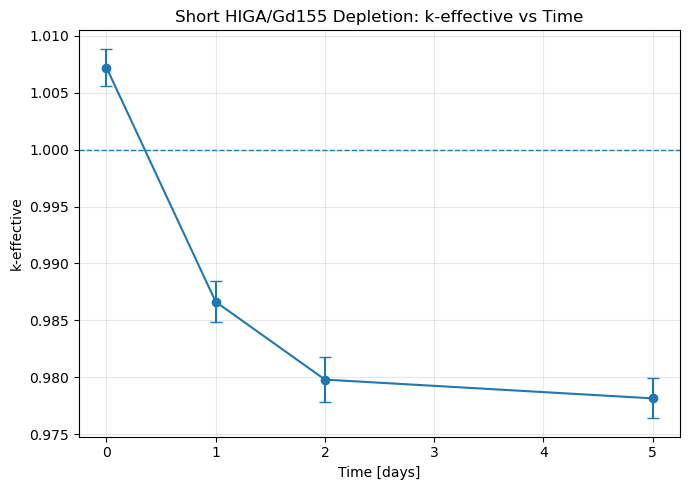

Saved CSV    = aegis40_HIGA_Gd155_short_depletion_keff.csv
Saved figure = aegis40_HIGA_Gd155_short_depletion_keff.png


In [16]:
###############################################################################
# 9. READ SHORT DEPLETION RESULTS
###############################################################################

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openmc.deplete

results_path = os.path.join(DEPLETION_RESULTS_DIR, "depletion_results.h5")

print(f"Reading depletion results from: {results_path}")

results = openmc.deplete.Results(results_path)

times_s, keffs = results.get_keff()

times_s = np.asarray(times_s, dtype=float)
keffs = np.asarray(keffs)

times_days = times_s / (24.0 * 3600.0)

if keffs.ndim == 2 and keffs.shape[1] >= 2:
    keff_mean = keffs[:, 0]
    keff_sigma = keffs[:, 1]
else:
    keff_mean = np.array([k.n for k in keffs])
    keff_sigma = np.array([k.s for k in keffs])

rho_pcm_values = 1.0e5 * (keff_mean - 1.0) / keff_mean
rho_sigma_pcm_values = 1.0e5 * keff_sigma / (keff_mean ** 2)

df_keff_burn = pd.DataFrame({
    "time_days": times_days,
    "keff": keff_mean,
    "keff_sigma": keff_sigma,
    "keff_sigma_pcm": keff_sigma * 1.0e5,
    "rho_pcm": rho_pcm_values,
    "rho_sigma_pcm": rho_sigma_pcm_values
})

csv_name = "aegis40_HIGA_Gd155_short_depletion_keff.csv"
fig_name = "aegis40_HIGA_Gd155_short_depletion_keff.png"

df_keff_burn.to_csv(csv_name, index=False)

print("=" * 72)
print("Short HIGA/Gd155 depletion k-effective results")
print("=" * 72)
print(df_keff_burn)
print("=" * 72)

plt.figure(figsize=(7, 5))
plt.errorbar(
    df_keff_burn["time_days"],
    df_keff_burn["keff"],
    yerr=df_keff_burn["keff_sigma"],
    fmt='o-',
    capsize=4
)
plt.axhline(1.0, linestyle='--', linewidth=1)
plt.xlabel("Time [days]")
plt.ylabel("k-effective")
plt.title("Short HIGA/Gd155 Depletion: k-effective vs Time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(fig_name, dpi=250)
plt.show()

print(f"Saved CSV    = {csv_name}")
print(f"Saved figure = {fig_name}")

In [17]:
###############################################################################
# DIAGNOSTIC A — Heavy Metal Mass and Burnup Scale Check
###############################################################################

# Approximate uranium mass from material volumes and weight fractions.
# This checks whether the depletion power/burnup scaling is reasonable.

UO2_DENSITY = 10.257  # g/cm3
URANIUM_WT_FRACTION_UO2 = 1.0 - oxygen_wt

fuel_material_volume_cm3 = (
    uo2_16.volume +
    uo2_24.volume +
    uo2_31.volume
)

uranium_mass_g = fuel_material_volume_cm3 * UO2_DENSITY * URANIUM_WT_FRACTION_UO2
uranium_mass_kg = uranium_mass_g / 1000.0
uranium_mass_MTU = uranium_mass_kg / 1000.0

print("=" * 72)
print("Heavy Metal / Burnup Scale Check")
print("=" * 72)
print(f"Total UO2 fuel volume       = {fuel_material_volume_cm3:.6e} cm3")
print(f"Approx uranium mass         = {uranium_mass_kg:.3f} kg")
print(f"Approx uranium mass         = {uranium_mass_MTU:.4f} MTU")
print("-" * 72)

for days in [1, 5, 10, 30]:
    burnup_GWd_per_MTU = (125.0 * days) / (1000.0 * uranium_mass_MTU)
    print(f"Burnup after {days:>2} days at 125 MWth = {burnup_GWd_per_MTU:.5f} GWd/MTU")

print("=" * 72)

Heavy Metal / Burnup Scale Check
Total UO2 fuel volume       = 8.873371e+05 cm3
Approx uranium mass         = 8085.699 kg
Approx uranium mass         = 8.0857 MTU
------------------------------------------------------------------------
Burnup after  1 days at 125 MWth = 0.01546 GWd/MTU
Burnup after  5 days at 125 MWth = 0.07730 GWd/MTU
Burnup after 10 days at 125 MWth = 0.15459 GWd/MTU
Burnup after 30 days at 125 MWth = 0.46378 GWd/MTU


In [18]:
###############################################################################
# DIAGNOSTIC B — Read Key Isotopes from Depletion Results
###############################################################################

import os
import numpy as np
import pandas as pd
import openmc.deplete

results_path = os.path.join(DEPLETION_RESULTS_DIR, "depletion_results.h5")
results = openmc.deplete.Results(results_path)

times_s, _ = results.get_keff()
times_days = np.asarray(times_s) / (24.0 * 3600.0)

# Material IDs as strings
mat_ids = {
    "inner_UO2": str(uo2_16.id),
    "middle_UO2": str(uo2_24.id),
    "outer_UO2": str(uo2_31.id),
    "HIGA": str(higa_absorber.id),
}

rows = []

for label, mat_id in mat_ids.items():
    for nuc in ["U235", "U238", "Pu239", "Pu240", "Pu241", "Gd155"]:
        try:
            t, atoms = results.get_atoms(mat_id, nuc)
            atoms = np.asarray(atoms)

            for day, atom_val in zip(times_days, atoms):
                rows.append({
                    "material": label,
                    "material_id": mat_id,
                    "nuclide": nuc,
                    "time_days": day,
                    "atoms": atom_val
                })

        except Exception:
            pass

df_iso = pd.DataFrame(rows)

print("=" * 72)
print("Available isotope tracking results")
print("=" * 72)
print(df_iso.head(40))
print("=" * 72)

df_iso.to_csv("aegis40_depletion_isotope_tracking.csv", index=False)
print("Saved CSV = aegis40_depletion_isotope_tracking.csv")

# Quick pivot for Gd155 and U235
for nuc in ["U235", "Gd155", "Pu239"]:
    df_nuc = df_iso[df_iso["nuclide"] == nuc]

    if len(df_nuc) > 0:
        print("\n" + "=" * 72)
        print(f"{nuc} atom inventory")
        print("=" * 72)
        print(df_nuc.pivot_table(
            index="time_days",
            columns="material",
            values="atoms",
            aggfunc="first"
        ))

Available isotope tracking results
      material material_id nuclide  time_days         atoms
0    inner_UO2           1    U235        0.0  1.310188e+26
1    inner_UO2           1    U235        1.0  1.308995e+26
2    inner_UO2           1    U235        2.0  1.307828e+26
3    inner_UO2           1    U235        5.0  1.304333e+26
4    inner_UO2           1    U238        0.0  4.846169e+27
5    inner_UO2           1    U238        1.0  4.846100e+27
6    inner_UO2           1    U238        2.0  4.846031e+27
7    inner_UO2           1    U238        5.0  4.845822e+27
8    inner_UO2           1   Pu239        0.0  0.000000e+00
9    inner_UO2           1   Pu239        1.0  7.895486e+21
10   inner_UO2           1   Pu239        2.0  2.950926e+22
11   inner_UO2           1   Pu239        5.0  1.462961e+23
12   inner_UO2           1   Pu240        0.0  0.000000e+00
13   inner_UO2           1   Pu240        1.0  1.397750e+19
14   inner_UO2           1   Pu240        2.0  6.337798e+19
15   

In [19]:
###############################################################################
# DIAGNOSTIC — HIGA Gd Isotope Evolution
###############################################################################

import os
import numpy as np
import pandas as pd
import openmc.deplete

results_path = os.path.join(DEPLETION_RESULTS_DIR, "depletion_results.h5")
results = openmc.deplete.Results(results_path)

times_s, _ = results.get_keff()
times_days = np.asarray(times_s) / (24.0 * 3600.0)

higa_id = str(higa_absorber.id)

gadolinium_isotopes = [
    "Gd152", "Gd154", "Gd155", "Gd156",
    "Gd157", "Gd158", "Gd160"
]

rows = []

for nuc in gadolinium_isotopes:
    try:
        t, atoms = results.get_atoms(higa_id, nuc)
        atoms = np.asarray(atoms)

        for day, atom_val in zip(times_days, atoms):
            rows.append({
                "time_days": day,
                "nuclide": nuc,
                "atoms": atom_val
            })

    except Exception as err:
        print(f"Could not read {nuc}: {err}")

df_higa_gd = pd.DataFrame(rows)

print("=" * 72)
print("HIGA gadolinium isotope inventory")
print("=" * 72)

if len(df_higa_gd) > 0:
    table = df_higa_gd.pivot_table(
        index="time_days",
        columns="nuclide",
        values="atoms",
        aggfunc="first"
    )
    print(table)
    table.to_csv("aegis40_HIGA_gd_isotope_inventory.csv")
    print("Saved CSV = aegis40_HIGA_gd_isotope_inventory.csv")
else:
    print("No HIGA Gd isotope data found.")

print("=" * 72)

HIGA gadolinium isotope inventory
nuclide           Gd152         Gd154         Gd155         Gd156  \
time_days                                                           
0.0        0.000000e+00  0.000000e+00  2.918635e+26  0.000000e+00   
1.0        1.356832e+07  5.681997e+18  2.917327e+26  1.308496e+23   
2.0        1.424323e+08  1.215403e+19  2.915993e+26  2.642319e+23   
5.0        3.012685e+09  3.146866e+19  2.912034e+26  6.600932e+23   

nuclide           Gd157         Gd158         Gd160  
time_days                                            
0.0        0.000000e+00  0.000000e+00  0.000000e+00  
1.0        1.731702e+18  8.573312e+14  3.386172e+04  
2.0        7.054435e+18  7.074579e+15  1.061360e+06  
5.0        4.580787e+19  1.128068e+17  7.141367e+07  
Saved CSV = aegis40_HIGA_gd_isotope_inventory.csv
